In [1]:
from pyglam import *
import numpy as np

In [2]:
x = np.random.normal(0, 1, 50000)
# x = np.random.triangular(2, 4, 6, 50000)
# x = np.random.uniform(2, 6, 50000)
# x = np.random.exponential(scale=1./0.5, size=50000)
# x = np.random.gumbel(loc=4, scale=1, size=50000)
media = 0      # loc
desvio = 1     # scale
x_vals = np.linspace(media - 4*desvio, media + 4*desvio, 500)  # valores para PDF/CDF

In [3]:
g = GlamFKML()
sol = g.fit_lambdas(x, method="least_squares")  # ou method="root"
print(sol.x)          # lambdas estimados
print(sol.success)    # status
print(sol.message)

[0.00251029 1.45848339 0.13177565 0.13239563]
True
`gtol` termination condition is satisfied.


In [4]:
g = GlamFKML(*sol.x)
rvs_glam = g.rvs(size=1000)
ppf_glam = g.ppf(np.linspace(0.01, 0.99, 100))
pdf_glam = g.pdf(x_vals)
cdf_glam = g.cdf(x_vals)

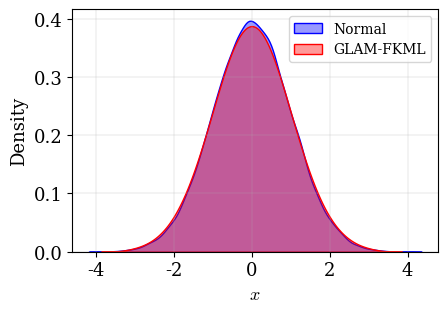

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
data = {
            'x': x,
            'y': rvs_glam
        }
### Figure name and DPI
dpi = 600                                                                               # Change as you wish
name = 'kde_histogram_compare' # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 12                                                   # Change as you wish
h_cm = 8                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_y = 'Density'
label_x = '$x$'                     # Change as you wish     
size_label = 13                     # Change as you wish
color_label = 'black'               # or hexadecimal. Change as you wish
size_axis = 13                      # Change as you wish
color_axis = 'black'                # or hexadecimal. Change as you wish

### Color KDE
color = ['blue', 'red']             # or hexadecimal. Change as you wish
alpha = 0.4                         # Change as you wish

### Legend. Do you need legend? Use the cell bellow:
legend_label = ['Normal', 'GLAM-FKML']    # Change as you wish
size_legend = 10                       # Change as you wish
location_legend = 'upper right'       # Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

### Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

### Plot with legend
sns.kdeplot(data=data, x='x', fill=True, alpha=alpha, ax=ax, color=color[0], label=legend_label[0])
sns.kdeplot(data=data, x='y', fill=True, alpha=alpha, ax=ax, color=color[1], label=legend_label[1])
### Legend. Do you need legend? Use the cell bellow:
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

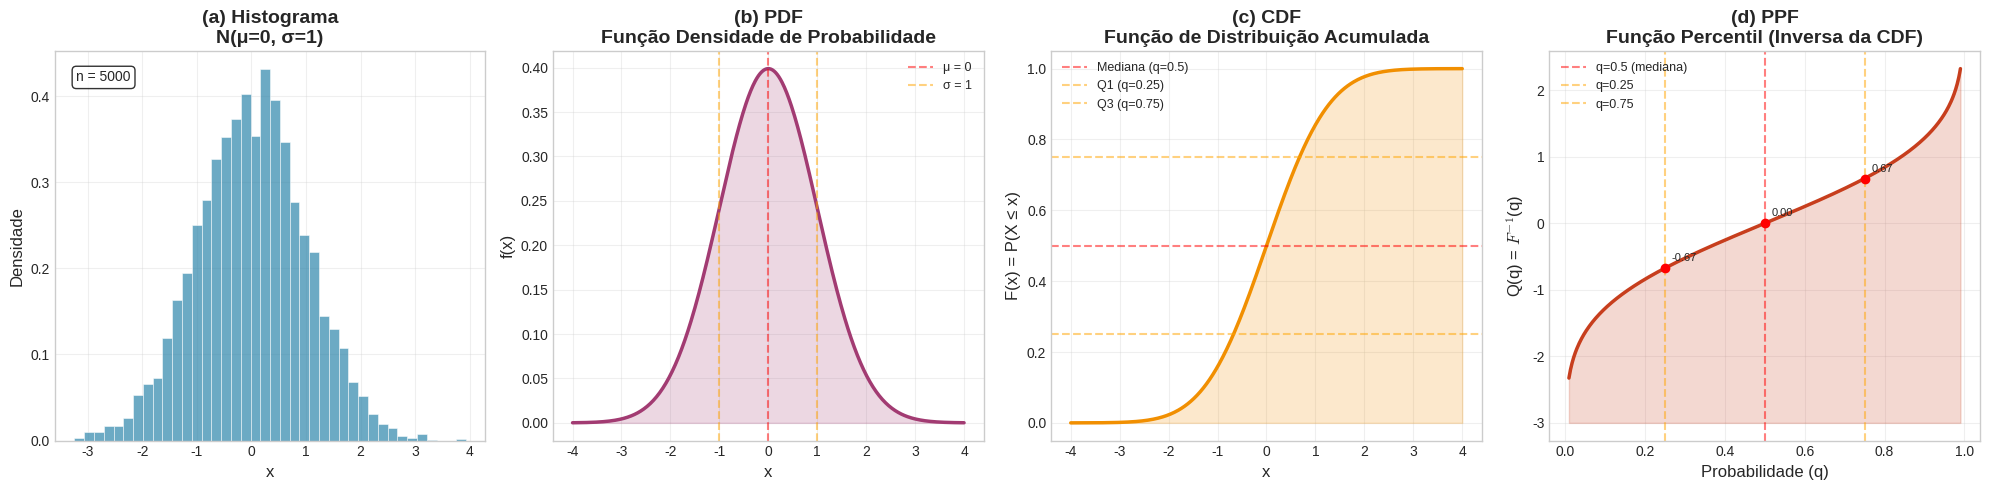

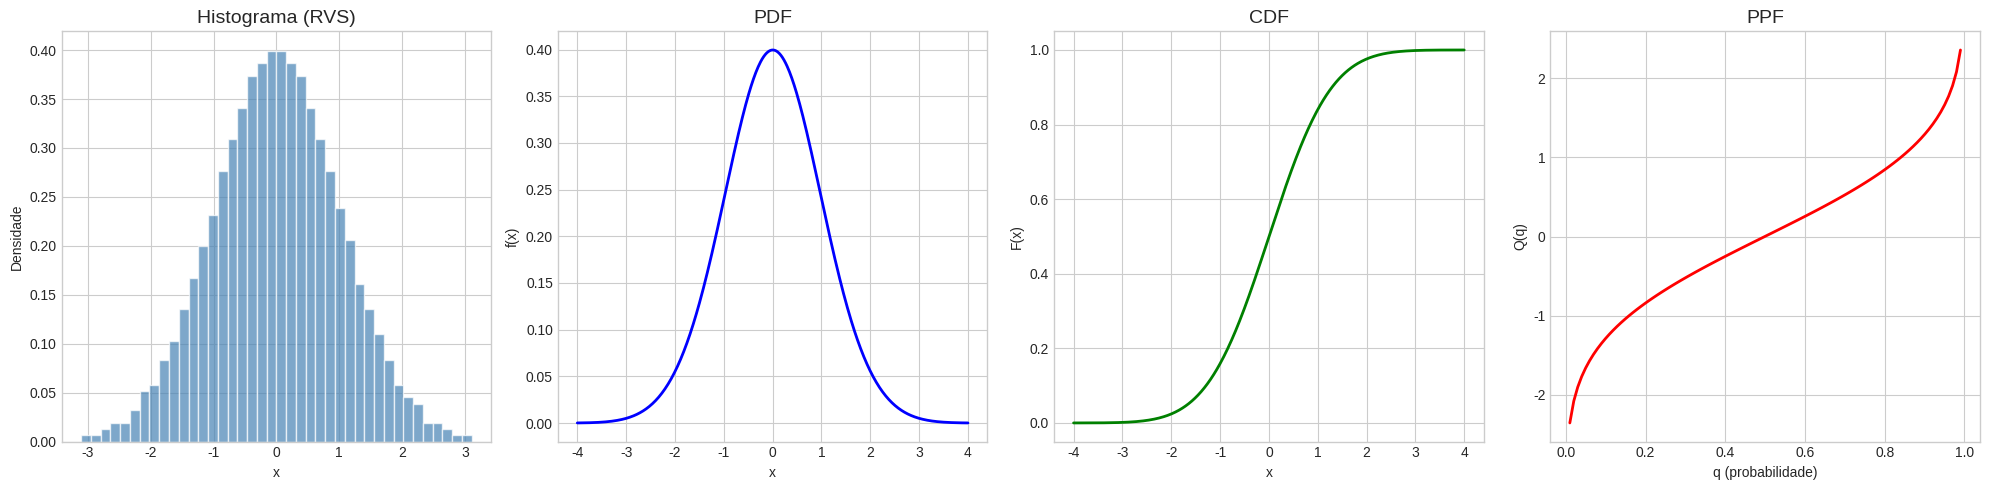

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================================
# PARÂMETROS DA DISTRIBUIÇÃO NORMAL
# ============================================

# Parâmetros da normal (você pode alterar)
media = 0      # loc
desvio = 1     # scale
x_vals = np.linspace(media - 4*desvio, media + 4*desvio, 500)  # valores para PDF/CDF

# Gerar dados aleatórios da normal
np.random.seed(42)
dados = stats.norm.rvs(loc=media, scale=desvio, size=5000)

# Criar valores para os gráficos
q_vals = np.linspace(0.01, 0.99, 500)  # probabilidades para PPF

# Calcular as funções
pdf_vals = stats.norm.pdf(x_vals, loc=media, scale=desvio)
cdf_vals = stats.norm.cdf(x_vals, loc=media, scale=desvio)
ppf_vals = stats.norm.ppf(q_vals, loc=media, scale=desvio)

# ============================================
# CRIAR FIGURA COM 1 LINHA E 4 COLUNAS
# ============================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Personalizar cores
cores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# --------------------------------------------
# 1. Histograma dos dados (RVS)
# --------------------------------------------
axes[0].hist(dados, bins=40, density=True, alpha=0.7, color=cores[0], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Densidade', fontsize=12)
axes[0].set_title(f'(a) Histograma\nN(μ={media}, σ={desvio})', fontsize=14, fontweight='bold')
axes[0].text(0.05, 0.95, f'n = {len(dados)}', transform=axes[0].transAxes, 
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].grid(True, alpha=0.3)

# --------------------------------------------
# 2. PDF (Probability Density Function)
# --------------------------------------------
axes[1].plot(x_vals, pdf_vals, linewidth=2.5, color=cores[1])
axes[1].fill_between(x_vals, 0, pdf_vals, alpha=0.2, color=cores[1])
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('f(x)', fontsize=12)
axes[1].set_title('(b) PDF\nFunção Densidade de Probabilidade', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Destacar pontos importantes na PDF
axes[1].axvline(x=media, color='red', linestyle='--', alpha=0.5, label=f'μ = {media}')
axes[1].axvline(x=media + desvio, color='orange', linestyle='--', alpha=0.5, label=f'σ = {desvio}')
axes[1].axvline(x=media - desvio, color='orange', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=9)

# --------------------------------------------
# 3. CDF (Cumulative Distribution Function)
# --------------------------------------------
axes[2].plot(x_vals, cdf_vals, linewidth=2.5, color=cores[2])
axes[2].fill_between(x_vals, 0, cdf_vals, alpha=0.2, color=cores[2])
axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('F(x) = P(X ≤ x)', fontsize=12)
axes[2].set_title('(c) CDF\nFunção de Distribuição Acumulada', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Destacar pontos importantes na CDF
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Mediana (q=0.5)')
axes[2].axhline(y=0.25, color='orange', linestyle='--', alpha=0.5, label='Q1 (q=0.25)')
axes[2].axhline(y=0.75, color='orange', linestyle='--', alpha=0.5, label='Q3 (q=0.75)')
axes[2].legend(fontsize=9)

# --------------------------------------------
# 4. PPF (Percent Point Function) - Inversa da CDF
# --------------------------------------------
axes[3].plot(q_vals, ppf_vals, linewidth=2.5, color=cores[3])
axes[3].fill_between(q_vals, media - 3*desvio, ppf_vals, alpha=0.2, color=cores[3], where=(ppf_vals > media - 3*desvio))
axes[3].set_xlabel('Probabilidade (q)', fontsize=12)
axes[3].set_ylabel('Q(q) = $F^{-1}$(q)', fontsize=12)
axes[3].set_title('(d) PPF\nFunção Percentil (Inversa da CDF)', fontsize=14, fontweight='bold')
axes[3].grid(True, alpha=0.3)

# Destacar pontos importantes na PPF
axes[3].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='q=0.5 (mediana)')
axes[3].axvline(x=0.25, color='orange', linestyle='--', alpha=0.5, label='q=0.25')
axes[3].axvline(x=0.75, color='orange', linestyle='--', alpha=0.5, label='q=0.75')

# Mostrar valores dos percentis
q_destaque = [0.25, 0.5, 0.75]
for q in q_destaque:
    valor = stats.norm.ppf(q, media, desvio)
    axes[3].plot(q, valor, 'ro', markersize=6)
    axes[3].annotate(f'{valor:.2f}', (q, valor), textcoords="offset points", 
                    xytext=(5, 5), fontsize=8)

axes[3].legend(fontsize=9)

# Ajustar layout
plt.tight_layout()
plt.show()

# ============================================
# VERSÃO MAIS SIMPLES (SEM MUITAS FIRULAS)
# ============================================

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

# Histograma
axes2[0].hist(rvs_glam, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes2[0].set_title('Histograma (RVS)', fontsize=14)
axes2[0].set_xlabel('x')
axes2[0].set_ylabel('Densidade')

# PDF
axes2[1].plot(x_vals, pdf_glam, 'b-', linewidth=2)
axes2[1].set_title('PDF', fontsize=14)
axes2[1].set_xlabel('x')
axes2[1].set_ylabel('f(x)')

# CDF
axes2[2].plot(x_vals, cdf_glam, 'g-', linewidth=2)
axes2[2].set_title('CDF', fontsize=14)
axes2[2].set_xlabel('x')
axes2[2].set_ylabel('F(x)')

# PPF
axes2[3].plot(np.linspace(0.01, 0.99, 100), ppf_glam, 'r-', linewidth=2)
axes2[3].set_title('PPF', fontsize=14)
axes2[3].set_xlabel('q (probabilidade)')
axes2[3].set_ylabel('Q(q)')

plt.tight_layout()
plt.show()

In [7]:
g = GlamFKML(*sol.x)
y = g.rvs(size=1000)
u = g.pdf([.25])
u

array([0.38714585])

In [8]:
u = g.cdf([-1., 0 , 1.])
u

array([0.15894709, 0.49903534, 0.83999704])